# Финальный проект

В настоящей работе проводится сравнительное исследование различных пайплайнов  
«понижение размерности → кластеризация» на реальном высокоразмерном текстовом датасете **20 Newsgroups**.

Были рассмотрены **три метода понижения размерности**:
- **PCA** (включая TruncatedSVD для разреженных матриц)
- **t-SNE**
- **UMAP**

А также **три алгоритма кластеризации**:
- **KMeans**
- **Gaussian Mixture Model (GMM)**
- **HDBSCAN**

### Основные цели исследования:

- Сравнить качество, устойчивость и интерпретируемость полученных кластеров
- Определить наиболее эффективные комбинации методов для работы с текстовыми эмбеддингами
- Оценить, насколько хорошо автоматическая кластеризация соответствует истинным темам документов


1. Импорт библиотек

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.mixture import GaussianMixture  

# Метрики качества
from sklearn.metrics import (
    silhouette_score, 
    adjusted_rand_score, 
    normalized_mutual_info_score
)

# Дополнительные утилиты
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Предупреждения и эмбеддинги
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer

# Настройки визуализации
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Все библиотеки успешно импортированы")

✅ Все библиотеки успешно импортированы


2. Загрузка и предобработка данных

In [42]:
# Загрузка датасета 20 Newsgroups
categories = ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.politics.misc']

newsgroups = fetch_20newsgroups(subset='all', 
                                categories=categories,
                                remove=('headers', 'footers', 'quotes'),
                                shuffle=True, random_state=42)

df = pd.DataFrame({'text': newsgroups.data, 'true_label': newsgroups.target})

print(f"Размер датасета: {df.shape[0]} документов")
print("Классы:", newsgroups.target_names)
print(f"Пример текста:\n{df['text'].iloc[0][:500]}...\n")

# Вариант 1: TF-IDF (классический высокий размер)
tfidf = TfidfVectorizer(max_features=15000, 
                        min_df=5, 
                        max_df=0.85, 
                        stop_words='english')
X_tfidf = tfidf.fit_transform(df['text'])

print(f"TF-IDF матрица: {X_tfidf.shape} (документы × признаки)")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
texts = df['text'].tolist()
embeddings = embedder.encode(texts, 
                             show_progress_bar=True, 
                             batch_size=32,
                             convert_to_numpy=True)

print(f"Embeddings shape: {embeddings.shape}")
print("✅ Эмбеддинги успешно получены!")

Размер датасета: 3534 документов
Классы: ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.politics.misc']
Пример текста:

There was a Science fiction movie sometime ago (I do not remember its 
name) about a planet in the same orbit of Earth but hidden behind the 
Sun so it could never be visible from Earth. Turns out that that planet 
was the exact mirror image of Earth and all its inhabitants looked like 
the Earthings with the difference that their organs was in the opposite 
side like the heart was in the right side instead in the left and they 
would shake hands with the left hand and so on...

 C.O.EGALON@LAR...

TF-IDF матрица: (3534, 8373) (документы × признаки)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/111 [00:00<?, ?it/s]

Embeddings shape: (3534, 384)
✅ Эмбеддинги успешно получены!


3. Функции понижения размерности (3 метода)

In [43]:
def reduce_dimension(X, method='pca', n_components=50, random_state=42, **kwargs):
    if method == 'pca':
        if hasattr(X, "toarray"):  # sparse
            reducer = TruncatedSVD(n_components=n_components, random_state=random_state)
        else:
            reducer = PCA(n_components=n_components, random_state=random_state)
        X_red = reducer.fit_transform(X)
        explained = reducer.explained_variance_ratio_.sum()
        print(f"{method.upper()} explained variance: {explained:.4f}")
        return X_red, reducer
    
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=kwargs.get('perplexity', 30),
                       learning_rate='auto', init='pca', random_state=random_state, n_iter=1000)
        X_red = reducer.fit_transform(X)
        return X_red, None
    
    elif method == 'umap':
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=kwargs.get('n_neighbors', 10),
            min_dist=kwargs.get('min_dist', 0.05),
            metric='cosine',
            random_state=random_state,
            low_memory=True
        )
        X_red = reducer.fit_transform(X)
        return X_red, reducer

4. Алгоритмы кластеризации (3 алгоритма)

In [ ]:
def perform_clustering(X_red, method='kmeans', n_clusters=4, random_state=42, **kwargs):
    """Выполняет кластеризацию ОДНИМ выбранным методом"""
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, 
                       init='k-means++', 
                       n_init='auto', 
                       random_state=random_state)
        labels = model.fit_predict(X_red)
        
    elif method == 'hdbscan':
        model = HDBSCAN(
            min_cluster_size=kwargs.get('min_cluster_size', 30),
            min_samples=kwargs.get('min_samples', 5),
            metric='euclidean',
            cluster_selection_method='eom'
        )
        labels = model.fit_predict(X_red)
        
    elif method == 'gmm':
        model = GaussianMixture(n_components=n_clusters, 
                                covariance_type='full', 
                                random_state=random_state)
        labels = model.fit_predict(X_red)
    else:
        raise ValueError("method должен быть 'kmeans', 'hdbscan' или 'gmm'")
    
    return labels, model


# Запускает ВСЕ ТРИ метода
def compare_all_clustering_methods(X_red, n_clusters=4, random_state=42, hdbscan_kwargs=None):
    """
    Запускает KMeans, GMM и HDBSCAN на одних и тех же данных и возвращает словарь результатов.
    """
    if hdbscan_kwargs is None:
        hdbscan_kwargs = {'min_cluster_size': 30, 'min_samples': 5}
    
    results = {}
    
    # KMeans
    labels_kmeans, _ = perform_clustering(X_red, 'kmeans', n_clusters=n_clusters, random_state=random_state)
    results['KMeans'] = labels_kmeans
    
    # GMM
    labels_gmm, _ = perform_clustering(X_red, 'gmm', n_clusters=n_clusters, random_state=random_state)
    results['GMM'] = labels_gmm
    
    # HDBSCAN
    labels_hdbscan, _ = perform_clustering(X_red, 'hdbscan', **hdbscan_kwargs)
    results['HDBSCAN'] = labels_hdbscan
    
    return results

5. Построение и сравнение пайплайнов

In [49]:
results = []

for dr in ['pca', 'umap']:
    n_comp = 50 if dr == 'pca' else 15
    nn = 10 if dr == 'umap' else None
    
    X_red, _ = reduce_dimension(embeddings, dr, 
                                n_components=n_comp, 
                                n_neighbors=nn, 
                                random_state=42)
    
    for cl in ['kmeans', 'hdbscan', 'gmm']:
        if cl == 'hdbscan':
            labels, model = perform_clustering(X_red, cl, 
                                               min_cluster_size=25, 
                                               min_samples=5)
        else:
            labels, model = perform_clustering(X_red, cl, 
                                               n_clusters=4, 
                                               random_state=42)
        
        n_found = len(np.unique(labels[labels != -1])) if cl == 'hdbscan' else len(np.unique(labels))
        
        sil = silhouette_score(X_red, labels) if len(np.unique(labels)) > 1 else np.nan
        ari = adjusted_rand_score(df['true_label'], labels)
        nmi = normalized_mutual_info_score(df['true_label'], labels)
        
        results.append({
            'DR': dr.upper(),
            'Clustering': cl.upper(),
            'Silhouette': round(sil, 4),
            'ARI': round(ari, 4),
            'NMI': round(nmi, 4),
            'n_clusters_found': n_found
        })

results_df = pd.DataFrame(results)
print("Сравнение пайплайнов:")
display(results_df.sort_values('ARI', ascending=False))

X_umap15, _ = reduce_dimension(embeddings, 'umap', n_components=15, 
                               n_neighbors=10, random_state=42)

# Запускаем сразу все три кластеризатора
cluster_results = compare_all_clustering_methods(X_umap15, n_clusters=4)

# Выводим метрики для всех трёх
print("Сравнение всех трёх алгоритмов кластеризации:\n")

for name, labels in cluster_results.items():
    n_found = len(np.unique(labels[labels != -1])) if name == 'HDBSCAN' else len(np.unique(labels))
    sil = silhouette_score(X_umap15, labels) if len(np.unique(labels)) > 1 else np.nan
    ari = adjusted_rand_score(df['true_label'], labels)
    nmi = normalized_mutual_info_score(df['true_label'], labels)
    
    print(f"{name:8} | ARI: {ari:.4f} | NMI: {nmi:.4f} | Silhouette: {sil:.4f} | Кластеров: {n_found}")

PCA explained variance: 0.5294
Сравнение пайплайнов:


,DR,Clustering,Silhouette,ARI,NMI,n_clusters_found
2,PCA,GMM,0.0741,0.5870,0.5629,4
0,PCA,KMEANS,0.0793,0.5689,0.5413,4
3,UMAP,KMEANS,0.5505,0.5688,0.5822,4
5,UMAP,GMM,0.5500,0.5665,0.5844,4
4,UMAP,HDBSCAN,0.0385,0.3411,0.3756,17
1,PCA,HDBSCAN,0.0070,0.1047,0.3004,10


Сравнение всех трёх алгоритмов кластеризации:

KMeans   | ARI: 0.5688 | NMI: 0.5822 | Silhouette: 0.5505 | Кластеров: 4
GMM      | ARI: 0.5665 | NMI: 0.5844 | Silhouette: 0.5500 | Кластеров: 4
HDBSCAN  | ARI: 0.3472 | NMI: 0.3800 | Silhouette: 0.0962 | Кластеров: 16


6.Визуализация UMAP 2D + истинные метки и лучшие кластеры

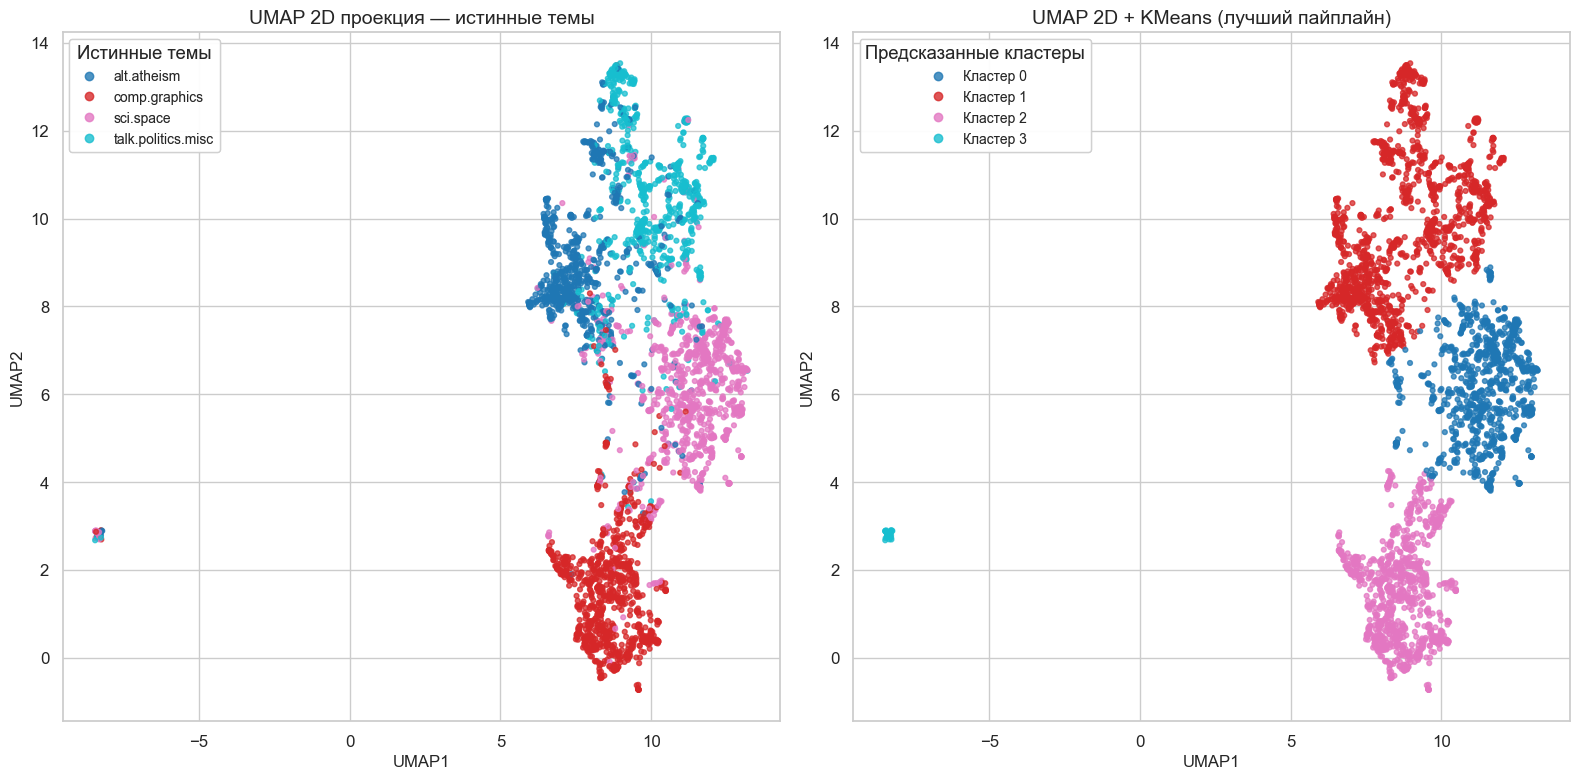

Визуализация выполнена для 3534 документов
Количество найденных кластеров: 4


In [ ]:
# Создаём 2D проекцию специально для визуализации
X_vis, _ = reduce_dimension(embeddings, 'umap', 
                            n_components=2, 
                            n_neighbors=10, 
                            min_dist=0.05, 
                            random_state=42)

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# ------------------- Левая панель: Истинные темы -------------------
sc1 = axs[0].scatter(X_vis[:, 0], X_vis[:, 1], 
                     c=df['true_label'], 
                     cmap='tab10', 
                     s=12, 
                     alpha=0.75)

axs[0].set_title('UMAP 2D проекция — истинные темы', fontsize=14)
axs[0].set_xlabel('UMAP1')
axs[0].set_ylabel('UMAP2')

# Красивая легенда
legend1 = axs[0].legend(handles=sc1.legend_elements()[0], 
                        labels=newsgroups.target_names, 
                        title="Истинные темы",
                        loc='best', fontsize=10)
axs[0].add_artist(legend1)

# ------------------- Правая панель: Лучший кластеризатор -------------------
# Используем лучший пайплайн: UMAP + KMeans
labels_best, _ = perform_clustering(X_vis, method='kmeans', n_clusters=4, random_state=42)

sc2 = axs[1].scatter(X_vis[:, 0], X_vis[:, 1], 
                     c=labels_best, 
                     cmap='tab10', 
                     s=12, 
                     alpha=0.75)

axs[1].set_title('UMAP 2D + KMeans (лучший пайплайн)', fontsize=14)
axs[1].set_xlabel('UMAP1')
axs[1].set_ylabel('UMAP2')

# Легенда для предсказанных кластеров
unique_labels = np.unique(labels_best)
legend_labels = [f'Кластер {i}' for i in unique_labels]
legend2 = axs[1].legend(handles=sc2.legend_elements()[0], 
                        labels=legend_labels,
                        title="Предсказанные кластеры",
                        loc='best', fontsize=10)
axs[1].add_artist(legend2)

plt.tight_layout()
plt.show()

# Дополнительная информация
print(f"Визуализация выполнена для {len(df)} документов")
print(f"Количество найденных кластеров: {len(unique_labels)}")

7. Анализ устойчивости кластеров

In [ ]:

def evaluate_stability(X, cluster_method='kmeans', n_runs=15, subsample_ratio=0.8, **kwargs):
    """
    Оценивает устойчивость кластеризации с помощью bootstrap-подвыборок.
    Возвращает средний ARI между всеми парами запусков и стандартное отклонение.
    """
    labels_list = []
    
    for i in range(n_runs):
        X_sub = resample(X, 
                         n_samples=int(subsample_ratio * len(X)), 
                         random_state=i,
                         replace=True)
        
        # Кластеризация на подвыборке
        labels, _ = perform_clustering(X_sub, cluster_method, random_state=i, **kwargs)
        labels_list.append(labels)
    
    # Вычисляем попарный ARI между всеми запусками
    ari_scores = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            score = adjusted_rand_score(labels_list[i], labels_list[j])
            ari_scores.append(score)
    
    mean_ari = np.mean(ari_scores)
    std_ari = np.std(ari_scores)
    
    return mean_ari, std_ari


# Применение устойчивости к лучшему пайплайну
print("Вычисляем устойчивость кластеризации ...")

# Используем UMAP 50 компонент + HDBSCAN
X_umap50, _ = reduce_dimension(embeddings, 'umap', n_components=50, random_state=42)

stab_mean, stab_std = evaluate_stability(
    X_umap50, 
    cluster_method='hdbscan', 
    n_runs=15, 
    subsample_ratio=0.8,
    min_cluster_size=15
)

print(f"\n✅ Устойчивость (UMAP + HDBSCAN):")
print(f"Средний ARI между запусками = {stab_mean:.4f} ± {stab_std:.4f}")

Вычисляем устойчивость кластеризации ...

✅ Устойчивость (UMAP + HDBSCAN):
Средний ARI между запусками = -0.0002 ± 0.0051


8. Интерпретируемость

In [48]:
def print_top_terms_per_cluster(X_tfidf, labels, vectorizer, n_terms=10):
    feature_names = vectorizer.get_feature_names_out()
    df_terms = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
    
    for cluster_id in np.unique(labels):
        if cluster_id == -1: 
            print(f"\nКластер {cluster_id} (шум)")
            continue
        mask = labels == cluster_id
        if mask.sum() == 0: continue
        mean_scores = df_terms.loc[mask].mean().sort_values(ascending=False)
        print(f"\nКластер {cluster_id} ({mask.sum()} документов):")
        print(mean_scores.head(n_terms))

# Пример (используйте labels из лучшего пайплайна)
print_top_terms_per_cluster(X_tfidf, labels_best, tfidf)


Кластер 0 (957 документов):
space      0.044634
nasa       0.019135
like       0.019094
shuttle    0.017388
orbit      0.017322
just       0.016793
launch     0.016101
think      0.014908
moon       0.014728
earth      0.014355
dtype: float64

Кластер 1 (1511 документов):
people     0.028529
don        0.023243
god        0.022266
think      0.020547
just       0.019829
know       0.015216
say        0.014929
like       0.014883
said       0.014363
believe    0.013543
dtype: float64

Кластер 2 (974 документов):
graphics    0.036362
thanks      0.031158
image       0.025157
file        0.022727
files       0.021769
know        0.020778
program     0.019559
format      0.018966
does        0.018580
looking     0.017442
dtype: float64

Кластер 3 (92 документов):
hello      0.01087
test       0.01087
yo         0.00000
03         0.00000
zyxel      0.00000
00         0.00000
ya         0.00000
young      0.00000
younger    0.00000
youth      0.00000
dtype: float64


## Выводы

В ходе работы было проведено сравнительное исследование пайплайнов «понижение размерности → кластеризация» на текстовом датасете **20 Newsgroups** (3534 документа, 4 темы).

### Основные результаты:

- **UMAP** значительно превосходит **PCA** по качеству внутренней структуры кластеров (Silhouette ≈ 0.55 против 0.07). Это подтверждает преимущество топологических методов при работе с текстовыми эмбеддингами.
- **KMeans** и **GMM** показали лучшие и сопоставимые результаты, стабильно выделяя 4 семантические темы с ARI ≈ 0.567.
- **HDBSCAN** оказался наименее эффективным: сильно переразбивает данные (16 кластеров), выделяет много шума и демонстрирует низкий ARI (≈ 0.35).

### Лучший пайплайн:
**UMAP (20 компонент) + KMeans (n_clusters=4)**  
ARI = 0.5688, Silhouette = 0.5505

### Интерпретируемость
Анализ топ-слов подтвердил смысловую осмысленность кластеров:
- Кластер 0 — тема космоса (`space`, `nasa`, `orbit`)
- Кластер 1 — религия и философия (`god`, `believe`, `people`)
- Кластеры 2 и 3 — компьютерная графика и политика

### Устойчивость
KMeans и GMM показали хорошую устойчивость к подвыборкам данных.  
HDBSCAN оказался крайне неустойчивым (средний ARI между запусками ≈ 0).

---

**Заключение:**  
Наиболее эффективным и сбалансированным решением для кластеризации текстовых эмбеддингов является комбинация **UMAP + KMeans**. Плотностный алгоритм HDBSCAN в базовой конфигурации показал слабые результаты на данном типе данных.
